# Loading

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [63]:
BASEDIR = "../LOGS"

runs = pd.read_csv(os.path.join(BASEDIR, "runs.csv"))
search_info = pd.read_csv(os.path.join(BASEDIR, "search_settings.csv"))
dataset_info = pd.read_csv(os.path.join(BASEDIR, "dataset_settings.csv"))

# Join the two settings dataframes on dataset_file
info = pd.merge(search_info, dataset_info, on='dataset_file')

# Join the two dataframes where runs['settings_id'] is the id of the search settings
df = pd.merge(runs, info, left_on='settings_id', right_on='id_x')

print(df.columns)

df.head()

Index(['id', 'settings_id', 'query_id', 'query_length', 'query_channels',
       'result_set_ts_indices', 'result_set_ts_positions',
       'result_set_distances', 'num_leaves_visited', 'num_nodes_visited',
       'num_ts_examined', 'total_time_s', 'first_layer_time_s',
       'tree_traversal_time_s', 'io_time_s', 'ts_examination_time_s', 'id_x',
       'index_file', 'dataset_file', 'ffts_file', 'query_file', 'num_queries',
       'query_type', 'r_range_r', 'knn_k', 'exact', 'normalized',
       'search_method', 'distance_measure', 'id_y', 'series_length',
       'num_channels', 'num_series'],
      dtype='object')


,id,settings_id,query_id,query_length,query_channels,result_set_ts_indices,result_set_ts_positions,result_set_distances,num_leaves_visited,num_nodes_visited,...,r_range_r,knn_k,exact,normalized,search_method,distance_measure,id_y,series_length,num_channels,num_series
0,0,0,0,128,0;1;0;0,86,328,0.067450,0,0,...,NaN,1,1,1,sequential_scan,ed,0,512,4,10000
1,1,0,1,128,1;0;0;0,96,2,0.246776,0,0,...,NaN,1,1,1,sequential_scan,ed,0,512,4,10000
2,2,0,2,512,1;1;1;1,120,0,0.471716,0,0,...,NaN,1,1,1,sequential_scan,ed,0,512,4,10000
3,3,0,3,256,1;1;1;1,126,62,0.802176,0,0,...,NaN,1,1,1,sequential_scan,ed,0,512,4,10000
4,4,0,4,256,0;0;0;1,127,152,0.202972,0,0,...,NaN,1,1,1,sequential_scan,ed,0,512,4,10000


In [64]:
# Infer necessary columns
ALGOS = ['BRUTE_FORCE', 'MASS', 'MULISSE']

# Algorithm -- dependent on combinations of search method and distance measure
def get_algorithm(row):
    search_method = row.search_method
    distance_measure = row.distance_measure
    ffts_precomputed = not pd.isna(row.ffts_file)

    if 'scan' in search_method and distance_measure == 'ed' and not ffts_precomputed:
        return 'BRUTE_FORCE'
    elif 'scan' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MASS'
    elif 'isax' in search_method and distance_measure == 'ed':
        return 'MULISSE_ED'
    elif 'isax' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MULISSE'
    else:
        return np.nan
    
df['algorithm'] = df.apply(get_algorithm, axis=1)

df['dataset'] = df.dataset_file.str.extract(r'(\w+).bin')

df['num_query_channels'] = df.query_channels.str.count('1')

df[['algorithm', 'dataset', 'num_query_channels']]

,algorithm,dataset,num_query_channels
0,BRUTE_FORCE,test_big,1
1,BRUTE_FORCE,test_big,1
2,BRUTE_FORCE,test_big,4
3,BRUTE_FORCE,test_big,4
4,BRUTE_FORCE,test_big,1
...,...,...,...
1342,MULISSE,test_big,2
1343,MULISSE,test_big,4
1344,MULISSE,test_big,4
1345,MULISSE,test_big,1


# Test

In [65]:
view = df[
    (df.algorithm.isna() == False) &
    (df.dataset == 'test_big')
]

view.groupby(['algorithm', 'query_length', 'num_query_channels']).size().unstack()

num_query_channels         1   2   3   4
algorithm   query_length                
BRUTE_FORCE 128           24  24  25  27
            256           22  35  17  26
            512           24  32  24  20
MASS        128           35  39  38  35
            256           32  57  26  39
            512           33  48  37  28
MULISSE     128           24  24  25  27
            256           22  35  17  26
            512           24  32  24  20
MULISSE_ED  128           24  24  25  27
            256           22  35  17  26
            512           24  32  24  20

In [66]:
view.groupby(['algorithm', 'query_length', 'num_query_channels']).total_time_s.median().unstack()

num_query_channels               1         2         3         4
algorithm   query_length                                        
BRUTE_FORCE 128           1.403394  2.869579  4.325861  5.693105
            256           1.983198  4.136695  5.991621  8.040181
            512           0.044091  0.065200  0.082898  0.102952
MASS        128           0.446508  0.835263  1.337938  1.712784
            256           0.435720  0.853350  1.273635  1.700079
            512           0.433132  0.856799  1.210160  1.640629
MULISSE     128           0.430430  0.764151  1.139256  1.491282
            256           0.420733  0.777870  1.149603  1.473397
            512           0.174698  0.136003  0.078633  0.036698
MULISSE_ED  128           0.313375  0.560925  1.029504  1.400798
            256           0.400070  0.571266  1.599461  2.291123
            512           0.018897  0.013798  0.010316  0.007768

<AxesSubplot:xlabel='algorithm'>

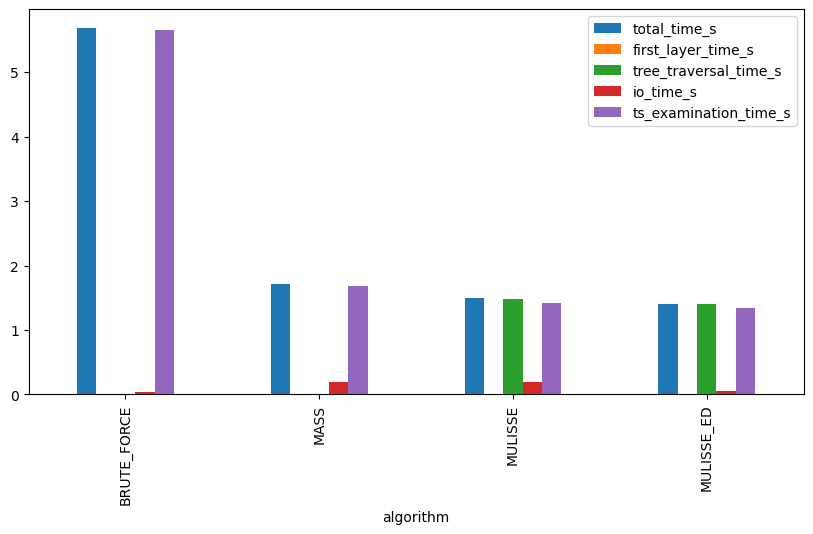

In [67]:
# Something weird is going on. Let's look at the intermediate times for each of the algorithms to get a better picture

tmp = view[
    (view.num_query_channels == 4) &
    (view.query_length == 128)
]

tmp.groupby(['algorithm'])[['total_time_s', 'first_layer_time_s', 'tree_traversal_time_s', 'io_time_s', 'ts_examination_time_s']].median().plot(kind='bar', figsize=(10, 5))

In [68]:
tmp.groupby(['algorithm']).num_ts_examined.median()

algorithm
BRUTE_FORCE    10000.0
MASS           10000.0
MULISSE         9846.0
MULISSE_ED      9846.0
Name: num_ts_examined, dtype: float64